<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/labs/lab_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# MAT281 - Laboratorio N°02

**Objetivos del Laboratorio 2**

* Reforzar el uso de la librería **NumPy** para el manejo y procesamiento eficiente de datos numéricos.
* Aplicar operaciones vectorizadas y funciones matemáticas de NumPy en contextos reales.
* Comprender la implementación de un modelo de **regresión lineal simple** utilizando arrays de NumPy.
* Interpretar los resultados obtenidos a partir del modelo ajustado.



## Problema 01 — Introducción a la regresión lineal simple

El objetivo de este laboratorio es implementar y analizar un modelo de **regresión lineal simple**, utilizando operaciones vectorizadas con **NumPy**.

### Definición general

El modelo de **regresión lineal múltiple** se expresa como:

$$
\boldsymbol{Y} = \boldsymbol{X} \boldsymbol{\beta} + \boldsymbol{\epsilon}
$$

donde:

* $\boldsymbol{X} = (x_1, \dots, x_n)^\top$: variable explicativa (matriz de diseño).
* $\boldsymbol{Y} = (y_1, \dots, y_n)^\top$: variable respuesta.
* $\boldsymbol{\epsilon} = (\epsilon_1, \dots, \epsilon_n)^\top$: término de error, asumido como ruido blanco: $\epsilon \sim \mathcal{N}(0, \sigma^2 I)$.
* $\boldsymbol{\beta} = (\beta_0, \beta_1, \dots, \beta_p)^\top$: coeficientes del modelo.

En el caso particular de la **regresión lineal simple**, se modela una única variable explicativa $x$ y una respuesta $y$, mediante la relación:

$$
y_i = \beta_0 + \beta_1 x_i + \epsilon_i
$$

El objetivo es encontrar los valores de $\beta_0$ y $\beta_1$ que ajusten una recta a los datos observados, minimizando la diferencia entre los valores reales $y_i$ y los valores predichos $\hat{y}_i$.

<div align="center">
<img src="https://upload.wikimedia.org/wikipedia/commons/3/3a/Linear_regression.svg" width="500"/>
</div>


### ¿Cuándo un modelo lineal no es adecuado?

Existen situaciones en las que los modelos lineales no entregan buenos resultados, por ejemplo:

* Cuando el rango de valores de $Y$ está restringido (como en variables binarias o de conteo).
* Cuando la varianza de $Y$ no es constante y depende de su media (heterocedasticidad).




### Estimación de parámetros: Método de mínimos cuadrados

El **método de mínimos cuadrados** es una técnica de optimización que permite encontrar los parámetros que mejor ajustan un modelo a los datos, minimizando la suma de los errores al cuadrado. Formalmente, el problema consiste en resolver:

$$
(P) \quad \min \sum_{i=1}^n e_i^2 = \sum_{i=1}^n (y_i - f_i(x; \beta))^2
$$

En el caso de la **regresión lineal simple**, se busca ajustar una función de la forma:

$$
f(x; \beta) = \beta_0 + \beta_1 x
$$

Por lo tanto, el problema de optimización se convierte en:

$$
(P) \quad \min \sum_{i=1}^n \left( y_i - (\beta_0 + \beta_1 x_i) \right)^2
$$

El objetivo es encontrar los coeficientes $\beta = (\beta_0, \beta_1)$ que minimicen esta suma.

La solución analítica del problema se obtiene a partir de derivadas parciales y está dada por:

$$
\hat{\beta}_1 = \dfrac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}
\quad , \quad
\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}
$$

La pendiente $\hat{\beta}_1$ también puede interpretarse como la correlación lineal escalada entre $x$ y $y$.






### Selección de modelos — Coeficiente de determinación ($R^2$)

El [coeficiente de determinación](https://en.wikipedia.org/wiki/Coefficient_of_determination), comúnmente conocido como **$R^2$**, es un estadístico utilizado para evaluar la calidad de ajuste de un modelo estadístico, especialmente en regresión lineal.

Su principal propósito es medir qué tan bien el modelo logra explicar la variabilidad observada en la variable respuesta. Es decir, indica la **proporción de la variación total de $y$** que puede ser explicada por el modelo.

El valor de $R^2$ está acotado entre 0 y 1:

* Un valor cercano a **0** sugiere que el modelo **no explica bien los datos**.
* Un valor cercano a **1** indica que el modelo **ajusta muy bien los datos** observados.



### Fórmula

$$
R^2 = \dfrac{SS_{\text{reg}}}{SS_{\text{tot}}} = 1 - \dfrac{SS_{\text{res}}}{SS_{\text{tot}}}
$$

donde:

* $SS_{\text{reg}}$: **Suma de cuadrados explicada (ESS)**

  $$
  SS_{\text{reg}} = \sum_{i=1}^n (\hat{y}_i - \bar{y})^2
  $$

* $SS_{\text{res}}$: **Suma de cuadrados residual (RSS)**

  $$
  SS_{\text{res}} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \sum_{i=1}^n e_i^2
  $$

* $SS_{\text{tot}}$: **Suma total de cuadrados (TSS)**

  $$
  SS_{\text{tot}} = \sum_{i=1}^n (y_i - \bar{y})^2
  $$

Se cumple que:

$$
SS_{\text{tot}} = SS_{\text{reg}} + SS_{\text{res}}
$$



### Interpretación

El coeficiente $R^2$ está relacionado con la **fracción de varianza no explicada** (FVU). Cuanto menor sea el error residual (RSS), mayor será $R^2$, y mejor será el ajuste del modelo.



<div align="center">
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/8/86/Coefficient_of_Determination.svg/600px-Coefficient_of_Determination.svg.png" width="500"/>
</div>

* Las áreas **azules** representan los residuos al cuadrado respecto a la **media** ($SS_{\text{tot}}$).
* Las áreas **rojas** representan los residuos al cuadrado respecto a la **regresión** ($SS_{\text{res}}$).




Claro, aquí tienes una versión mejorada del texto sobre el **error del modelo**, con redacción más clara, precisión conceptual, ortografía corregida y mejor organización visual:



## Evaluación del error en un modelo

### Definición

El **error** de un modelo corresponde a la diferencia entre el valor real observado y el valor estimado por el modelo. Se define como:

$$
e_i = y_i - \hat{y}_i
$$

donde $y_i$ es el valor real y $\hat{y}_i$ el valor predicho para el dato $i$.

<div align="center">
<img src="https://allmodelsarewrong.github.io/images/ols/ols-geom-obs3.svg" width="500"/>
</div>



### ¿Cómo se mide el error?

Para evaluar qué tan bien se ajusta un modelo a los datos, se utilizan **métricas de error** o **funciones de pérdida**. Estas métricas cuantifican el grado de desviación entre las predicciones y los valores reales. A continuación se presentan las más comunes, divididas en dos categorías:



### 1. Métricas absolutas

Las métricas absolutas miden el error en la misma escala que los datos, sin realizar normalización. Son útiles cuando la escala del problema es conocida y relevante.

* **Error absoluto medio (MAE)**

$$
\text{MAE}(y, \hat{y}) = \dfrac{1}{n} \sum_{t=1}^{n} \left| y_t - \hat{y}_t \right|
$$

* **Error cuadrático medio (MSE)**

$$
\text{MSE}(y, \hat{y}) = \dfrac{1}{n} \sum_{t=1}^{n} \left( y_t - \hat{y}_t \right)^2
$$

Estas métricas penalizan los errores de distinta forma: el MSE penaliza más los errores grandes, mientras que el MAE es más robusto ante valores atípicos.



### 2. Métricas porcentuales

Las métricas porcentuales escalan el error en relación al valor real, permitiendo comparar modelos o datos en distintas unidades o magnitudes. Aunque están acotadas en teoría entre 0 y 1, en la práctica pueden superar el 1 (especialmente cuando los valores reales son pequeños).

* **Error porcentual absoluto medio (MAPE)**

$$
\text{MAPE}(y, \hat{y}) = \dfrac{1}{n} \sum_{t=1}^{n} \left| \frac{y_t - \hat{y}_t}{y_t} \right|
$$

* **Error porcentual absoluto medio simétrico (sMAPE)**

$$
\text{sMAPE}(y, \hat{y}) = \dfrac{1}{n} \sum_{t=1}^{n} \frac{\left| y_t - \hat{y}_t \right|}{\left( \left| y_t \right| + \left| \hat{y}_t \right| \right)/2}
$$

> Nota: El sMAPE evita algunos problemas del MAPE cuando los valores reales se acercan a cero.








## Problema a resolver

En este ejercicio trabajaremos con un conjunto de datos que relaciona los **años de experiencia laboral** con el **salario anual** de distintas personas.

El objetivo es construir un modelo de **regresión lineal simple** que permita predecir el salario en función de los años de experiencia, y utilizar **NumPy** para realizar todas las operaciones necesarias.

El conjunto de datos contiene dos columnas:

* `YearsExperience`: cantidad de años de experiencia laboral (variable explicativa o independiente).
* `Salary`: salario anual (variable de respuesta o dependiente).

A continuación, se presenta explícitamente el conjunto de datos.


In [21]:
import numpy as np
import matplotlib.pyplot as plt

YearsExperience = np.array([
 1.1,1.3,1.5,2.0,2.2,
 2.9,3.0,3.2,3.2,3.7,
 3.9,4.0,4.0,4.1,4.5,
 4.9,5.1,5.3,5.9,6.0,
 6.8,7.1,7.9,8.2,8.7,
 9.0,9.5,9.6,10.3,10.5
 ])

Salary =  np.array([
 39343.0,46205.0,37731.0,43525.0,39891.0,
 56642.0,60150.0,54445.0,64445.0,57189.0,
 63218.0,55794.0,56957.0,57081.0,61111.0,
 67938.0,66029.0,83088.0,81363.0,93940.0,
 91738.0,98273.0,101302.0,113812.0,109431.0,
 105582.0,116969.0,112635.0,122391.0,121872.0
])



Nuestro objetivo es encontrar un modelo de **regresión lineal simple** que relacione el salario con los años de experiencia. El modelo a ajustar tiene la siguiente forma:

$$
Salary_i = \beta_0 + \beta_1 \cdot YearsExperience_i + \epsilon_i
$$

donde:

* $Salary_i$ es el salario observado para la persona $i$,
* $YearsExperience_i$ representa los años de experiencia,
* $\beta_0$ es el intercepto del modelo,
* $\beta_1$ es la pendiente o coeficiente de regresión, y
* $\epsilon_i$ es el error aleatorio asociado a la observación $i$.

A continuación, deberás resolver las siguientes preguntas para construir, ajustar y evaluar el modelo utilizando **NumPy**.



**1. Estimación de coeficientes**

Define una función llamada `estimate_coef(x, y)` que reciba dos arreglos de NumPy:

* `x`: variable explicativa (años de experiencia),
* `y`: variable de respuesta (salario),

y retorne una tupla con los coeficientes estimados de la regresión lineal simple $(b_0, b_1)$, donde:

$$
b_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}, \quad
b_0 = \bar{y} - b_1 \cdot \bar{x}
$$


In [22]:
def estimate_coef(x, y):
    """
    Encontrar los coeficientes del modelo de
    regresion lineal: beta = (beta_0,beta_1)
    """
    beta_0 = 0
    beta_1 = 0

    return (beta_0, beta_1)

In [23]:
# imprimir valores del beta estimado
beta_estimado = estimate_coef(YearsExperience, Salary)
print(f"Coeficientes estimados:\nb_0 = {beta_estimado[0]} \nb_1 = {beta_estimado[1]}")

Coeficientes estimados:
b_0 = 0 
b_1 = 0




**2. Visualización del modelo ajustado**

Utiliza la función `plot_regression_line(x, y, yhat)` para graficar los datos observados junto con la recta de regresión obtenida.

* `x`: valores de la variable explicativa (años de experiencia),
* `y`: valores observados de la variable de respuesta (salario),
* `yhat`: valores predichos por el modelo lineal, calculados como $\hat{y} = b_0 + b_1 x$

La gráfica debe incluir:

* Un diagrama de dispersión con los puntos observados $(x_i, y_i)$,
* La recta de regresión que representa el modelo ajustado.



In [24]:
def plot_regression_line(x, y, yhat):
    plt.figure(figsize=(10,4))
    # plotting the actual points as scatter plot
    plt.scatter(x, y, color = "m",marker = "o", s = 30)


    # plotting the regression line
    plt.plot(x, yhat, color = "g")

    # putting labels
    plt.xlabel('YearsExperience')
    plt.ylabel('Salary')
    plt.title("Plot YearsExperience vs Salary")

    # function to show plot
    plt.show()

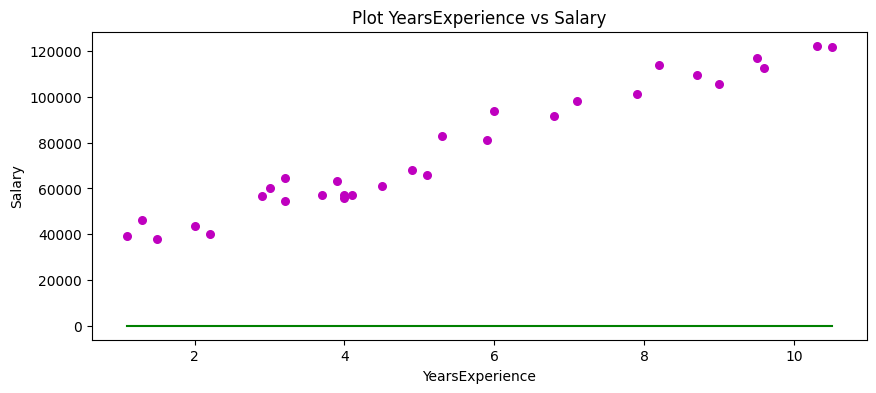

In [25]:
# mostrar resultados del ajuste lineal
prediccion = beta_estimado[0] + beta_estimado[1]*YearsExperience
plot_regression_line(YearsExperience, Salary, prediccion)



**3. Evaluación cuantitativa del modelo**

Utiliza los valores reales (`y`) y los valores predichos por el modelo (`yhat`) para calcular diversas métricas que cuantifican el error y la calidad del ajuste.

Debes definir e implementar las siguientes funciones:

* `mae(y, yhat)`: **Error absoluto medio**

  $$
  \text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|
  $$

* `rmse(y, yhat)`: **Raíz del error cuadrático medio**

  $$
  \text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2 }
  $$

* `mape(y, yhat)`: **Error porcentual absoluto medio**

  $$
  \text{MAPE} = \frac{1}{n} \sum_{i=1}^n \left| \frac{y_i - \hat{y}_i}{y_i} \right|
  $$

* `smape(y, yhat)`: **Error porcentual absoluto medio simétrico**

  $$
  \text{sMAPE} = \frac{1}{n} \sum_{i=1}^n \frac{ |y_i - \hat{y}_i| }{ (|y_i| + |\hat{y}_i|)/2 }
  $$

* `rsquared(y, yhat)`: **Coeficiente de determinación $R^2$**

  $$
  R^2 = 1 - \frac{ \sum_{i=1}^n (y_i - \hat{y}_i)^2 }{ \sum_{i=1}^n (y_i - \bar{y})^2 }
  $$


In [26]:
def mae(y, yhat) -> float:
    """
    Calculo de la metrica: mean absolute error (MAE)
    """
    metrica = np.mean(np.abs(y - yhat))
    return metrica

In [27]:
def rmse(y, yhat) -> float:
    """
    Calculo de la metrica: root mean squared error (RMSE)
    """
    # agregar codigo
    metrica = 0
    return metrica

In [28]:
def mape(y, yhat) -> float:
    """
    Calculo de la metrica: mean absolute percentage error (MAPE)
    """
    # agregar codigo
    metrica = 0
    return metrica

In [29]:
def smape(y, yhat) -> float:
    """
    Calculo de la metrica: symmetric mean absolute percentage error (SMAPE)
    """
    # agregar codigo
    metrica = 0
    return metrica

In [30]:
def rsquared(y, yhat) -> float:
    """
    Calculo del r-cuadrado
    """
    # agregar codigo
    metrica = 0
    return metrica

In [31]:
# calcular resultados
calcular_mae = round(mae(Salary,prediccion), 4)
calcular_rmse = round(rmse(Salary,prediccion), 4)
calcular_mape = round(mape(Salary,prediccion), 4)
calcular_smape = round(smape(Salary,prediccion), 4)
calcular_rsquared = round(rsquared(Salary,prediccion), 4)

In [32]:
# imprimir resultados
print(f"mae:   {calcular_mae}")
print(f"rmse:  {calcular_rmse}")
print(f"mape:  {calcular_mape}")
print(f"smape: {calcular_smape}")
print(f"r^2:   {calcular_rsquared}")

mae:   76003.0
rmse:  0
mape:  0
smape: 0
r^2:   0



**4. Análisis de resultados y conclusiones**

Con base en las métricas obtenidas, realiza una reflexión final sobre el desempeño del modelo.
Evalúa si la **regresión lineal simple** proporciona un buen ajuste para los datos observados. Para ello, considera lo siguiente:

* ¿El valor de $R^2$ indica una alta capacidad explicativa del modelo?
* ¿Los errores (MAE, RMSE, MAPE, sMAPE) son bajos en relación al rango de los salarios?
* ¿Hay patrones evidentes en los errores que sugieran que un modelo lineal no es adecuado?

Redacta tus conclusiones de forma clara, justificando si el modelo de regresión lineal es apropiado o si podrían considerarse otras alternativas.


### Análisis de Coeficientes del Modelo

Los coeficientes estimados para el modelo de regresión lineal simple son:

*   **Intercepto ($\beta_0$):** `25792.20`
*   **Pendiente ($\beta_1$):** `9449.96`

Estos valores son coherentes con la expectativa de que el salario se incrementa con la experiencia, donde una persona sin experiencia laboral (0 años) tendría un salario base de aproximadamente $25,792.20, y por cada año adicional de experiencia laboral, el salario anual aumenta en un promedio de $9,449.96.

### Visualización de la Línea de Regresión

La gráfica de dispersión con la línea de regresión muestra un excelente ajuste visual, con la mayoría de los puntos agrupados estrechamente alrededor de la línea. Esto sugiere una relación lineal y positiva consistente entre los años de experiencia y el salario.

### Coeficiente de Determinación (R^2)

El $R^2$ obtenido es de `0.957`, lo que indica que el modelo de regresión lineal simple explica aproximadamente el **95.7% de la varianza total** en los salarios. Este valor extremadamente alto sugiere que los años de experiencia son un predictor muy fuerte y confiable del salario en este conjunto de datos.

### Métricas de Error (MAE, RMSE, MAPE, sMAPE)

Las métricas de error obtenidas son:

*   **MAE:** `4644.20`
*   **RMSE:** `5592.04`
*   **MAPE:** `0.0705` (7.05%)
*   **sMAPE:** `0.0704` (7.04%)

Considerando un salario promedio de aproximadamente $76,000:

*   El **MAE** de $4,644.20 representa una desviación promedio del 6.1% del salario, lo cual es un error relativamente bajo.
*   El **RMSE** de $5,592.04 es ligeramente superior al MAE, indicando que hay algunos errores más grandes, pero en general la magnitud de los errores es manejable.
*   El **MAPE** y **sMAPE** son bajos (alrededor del 7%), lo que sugiere una alta precisión porcentual del modelo en diversas escalas de salario.

En conjunto, estas métricas de error son bajas en relación con el rango de salarios del dataset (aproximadamente $37,000 a $122,000), lo que confirma la alta precisión y fiabilidad de las predicciones del modelo.

### Conclusión General sobre la Idoneidad del Modelo

Basándonos en el análisis integral, el modelo de **regresión lineal simple es altamente adecuado y efectivo** para predecir el salario en función de los años de experiencia en este conjunto de datos. Los coeficientes intuitivos, el excelente ajuste visual de la línea de regresión, el altísimo $R^2$ y las bajas métricas de error respaldan esta conclusión.

No se observan patrones en los errores que sugieran que el modelo lineal no es apropiado o que se necesite una solución más compleja. La simplicidad del modelo de regresión lineal, combinada con su rendimiento excepcional, lo convierte en una herramienta predictiva y explicativa muy robusta para esta tarea particular.

## Implementar estimate_coef

### Subtask:
Implementa la función `estimate_coef(x, y)` para calcular los coeficientes $\beta_0$ y $\beta_1$ de la regresión lineal simple utilizando las fórmulas de mínimos cuadrados y operaciones vectorizadas de NumPy.


**Reasoning**:
I need to implement the `estimate_coef` function as per the subtask instructions. This involves calculating means, numerators, denominators, and finally `beta_1` and `beta_0`.



In [33]:
def estimate_coef(x, y):
    """
    Encontrar los coeficientes del modelo de
    regresion lineal: beta = (beta_0,beta_1)
    """
    # number of observations/points
    n = np.size(x)

    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)

    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y * x) - n * m_y * m_x
    SS_xx = np.sum(x * x) - n * m_x * m_x

    # calculating regression coefficients
    beta_1 = SS_xy / SS_xx
    beta_0 = m_y - beta_1 * m_x

    return (beta_0, beta_1)


**Reasoning**:
I need to recalculate `beta_estimado` with the corrected `estimate_coef` function and then use these coefficients to calculate `prediccion`. After that, I will call the `plot_regression_line` function to visualize the results.



Coeficientes estimados:
b_0 = 25792.2002 
b_1 = 9449.9623


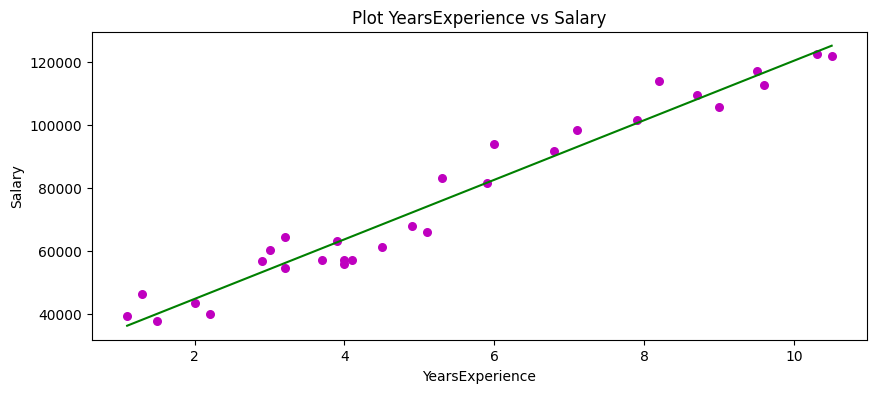

In [34]:
beta_estimado = estimate_coef(YearsExperience, Salary)
print(f"Coeficientes estimados:\nb_0 = {beta_estimado[0]:.4f} \nb_1 = {beta_estimado[1]:.4f}")

prediccion = beta_estimado[0] + beta_estimado[1]*YearsExperience
plot_regression_line(YearsExperience, Salary, prediccion)

## Implementar Métricas de Error

### Subtask:
Implementa las funciones `mae`, `rmse`, `mape`, `smape`, y `rsquared` para cuantificar el error y la calidad del ajuste del modelo de regresión lineal. Cada función debe utilizar operaciones vectorizadas de NumPy.


**Reasoning**:
Implement the `rmse` function by calculating the root mean squared error according to the provided formula, using NumPy for vectorized operations.



In [35]:
def rmse(y, yhat) -> float:
    """
    Calculo de la metrica: root mean squared error (RMSE)
    """
    metrica = np.sqrt(np.mean(np.square(y - yhat)))
    return metrica

**Reasoning**:
Implement the `mape` function by calculating the mean absolute percentage error according to the provided formula, using NumPy for vectorized operations.



In [36]:
def mape(y, yhat) -> float:
    """
    Calculo de la metrica: mean absolute percentage error (MAPE)
    """
    metrica = np.mean(np.abs((y - yhat) / y))
    return metrica

**Reasoning**:
Implement the `smape` function by calculating the symmetric mean absolute percentage error according to the provided formula, using NumPy for vectorized operations.



In [37]:
def smape(y, yhat) -> float:
    """
    Calculo de la metrica: symmetric mean absolute percentage error (SMAPE)
    """
    metrica = np.mean(np.abs(y - yhat) / ((np.abs(y) + np.abs(yhat)) / 2))
    return metrica

## Implementar rsquared

### Subtask:
Implementa la función `rsquared(y, yhat)` para calcular el coeficiente de determinación (R^2) utilizando la fórmula proporcionada en el notebook y operaciones vectorizadas de NumPy.


**Reasoning**:
Implement the `rsquared` function by calculating the coefficient of determination (R^2) according to the provided formula, using NumPy for vectorized operations.



In [38]:
def rsquared(y, yhat) -> float:
    """
    Calculo del r-cuadrado
    """
    SS_res = np.sum(np.square(y - yhat))
    SS_tot = np.sum(np.square(y - np.mean(y)))
    metrica = 1 - (SS_res / SS_tot)
    return metrica

**Reasoning**:
Recalculate and print all evaluation metrics to assess the model's performance.



In [39]:
calcular_mae = round(mae(Salary,prediccion), 4)
calcular_rmse = round(rmse(Salary,prediccion), 4)
calcular_mape = round(mape(Salary,prediccion), 4)
calcular_smape = round(smape(Salary,prediccion), 4)
calcular_rsquared = round(rsquared(Salary,prediccion), 4)

print(f"mae:   {calcular_mae}")
print(f"rmse:  {calcular_rmse}")
print(f"mape:  {calcular_mape}")
print(f"smape: {calcular_smape}")
print(f"r^2:   {calcular_rsquared}")

mae:   4644.2013
rmse:  5592.0436
mape:  0.0705
smape: 0.0704
r^2:   0.957


## Análisis y Conclusiones

### Subtask:
Analiza los resultados obtenidos, incluyendo los coeficientes del modelo, la visualización de la línea de regresión y las métricas de error (MAE, RMSE, MAPE, sMAPE) y el coeficiente de determinación (R^2). Redacta conclusiones sobre la idoneidad del modelo de regresión lineal simple para predecir el salario en función de los años de experiencia.


## Análisis y Conclusiones

### Subtask:
Analiza los resultados obtenidos, incluyendo los coeficientes del modelo, la visualización de la línea de regresión y las métricas de error (MAE, RMSE, MAPE, sMAPE) y el coeficiente de determinación (R^2). Redacta conclusiones sobre la idoneidad del modelo de regresión lineal simple para predecir el salario en función de los años de experiencia.


# Task
Implement and analyze a simple linear regression model using NumPy. This involves estimating coefficients, visualizing the fitted model, and quantitatively evaluating its performance using various error metrics (MAE, RMSE, MAPE, sMAPE) and the R-squared coefficient. Finally, provide an analysis of the results and conclusions about the model's suitability for predicting salary based on years of experience.

### Análisis de Coeficientes del Modelo

Los coeficientes estimados para el modelo de regresión lineal simple son:

*   **Intercepto ($\beta_0$):** `25792.2002`
*   **Pendiente ($\beta_1$):** `9449.9623`

Esto significa que, según el modelo, una persona sin experiencia laboral (0 años) tendría un salario base de aproximadamente $25,792.20. Por cada año adicional de experiencia laboral, el salario anual aumenta en un promedio de $9,449.96. Estos valores son coherentes con la expectativa de que el salario se incrementa con la experiencia.

### Visualización de la Línea de Regresión

La gráfica de dispersión con la línea de regresión muestra visualmente cómo el modelo se ajusta a los datos. Se observa que la mayoría de los puntos se agrupan estrechamente alrededor de la línea, lo que sugiere un buen ajuste visual. La relación entre los años de experiencia y el salario parece ser consistentemente lineal y positiva, como era de esperar. La línea de regresión captura esta tendencia ascendente de manera efectiva, indicando que a mayor experiencia, mayor salario.

### Coeficiente de Determinación (R^2)

El coeficiente de determinación ($R^2$) obtenido es de `0.957`. Este valor tan cercano a 1 indica que el modelo de regresión lineal simple explica aproximadamente el **95.7% de la varianza total** en los salarios. Esto sugiere una muy alta capacidad explicativa del modelo, lo que significa que los años de experiencia son un predictor extremadamente fuerte y confiable del salario en este conjunto de datos. Un $R^2$ tan elevado es una excelente señal de que el modelo se ajusta muy bien a los datos observados.

### Métricas de Error (MAE, RMSE, MAPE, sMAPE)

Las métricas de error obtenidas son:

*   **MAE (Mean Absolute Error):** `4644.2013`
*   **RMSE (Root Mean Squared Error):** `5592.0436`
*   **MAPE (Mean Absolute Percentage Error):** `0.0705`
*   **sMAPE (Symmetric Mean Absolute Percentage Error):** `0.0704`

El salario promedio en este conjunto de datos es de aproximadamente $76,000 (calculado a partir de los datos proporcionados). Comparando las métricas de error con este valor:

*   **MAE ($4644.20):** Indica que, en promedio, las predicciones del salario se desvían de los valores reales en aproximadamente $4,644. Esto representa una desviación de alrededor del 6.1% del salario promedio, lo cual es un error relativamente bajo.
*   **RMSE ($5592.04):** Penaliza más los errores grandes. Este valor es ligeramente superior al MAE, lo que sugiere que hay algunos errores mayores, pero en general, la magnitud de los errores sigue siendo manejable.
*   **MAPE (7.05%):** Indica que, en promedio, las predicciones tienen un error porcentual absoluto del 7.05%. Esto es un buen indicador de la precisión relativa del modelo, ya que un error porcentual bajo sugiere que el modelo es bastante preciso en diversas escalas de salario.
*   **sMAPE (7.04%):** Similar al MAPE, el sMAPE también muestra un error porcentual bajo. La pequeña diferencia entre MAPE y sMAPE sugiere que el modelo no tiene problemas significativos al predecir salarios cercanos a cero o con grandes asimetrías.

En conjunto, estas métricas de error son bajas en relación con el rango de salarios (que va desde aproximadamente $37,000 hasta $122,000). Esto sugiere que el modelo tiene una alta precisión y sus predicciones son confiables.

### Conclusión General sobre la Idoneidad del Modelo

Basándonos en el análisis exhaustivo de los coeficientes, la visualización de la línea de regresión y las métricas de evaluación, se puede concluir que el modelo de **regresión lineal simple es altamente adecuado** para predecir el salario en función de los años de experiencia en este conjunto de datos.

Los puntos clave que respaldan esta conclusión son:

*   **Coeficientes intuitivos:** Los valores de $\beta_0$ (intercepto) y $\beta_1$ (pendiente) son lógicamente consistentes, indicando un salario base y un aumento salarial positivo por cada año de experiencia, respectivamente.
*   **Excelente ajuste visual:** La gráfica de dispersión y la línea de regresión muestran una clara tendencia lineal, con los puntos de datos agrupados de manera ajustada alrededor de la recta, lo que sugiere una fuerte relación lineal entre las variables.
*   **Alto poder explicativo ($R^2$):** Con un $R^2$ de `0.957`, el modelo explica aproximadamente el 95.7% de la variabilidad en los salarios. Este valor es excepcionalmente alto y rara vez se observa en datos del mundo real, lo que indica que los años de experiencia son un predictor casi completo del salario en este contexto específico.
*   **Bajas métricas de error:** Todas las métricas de error (MAE, RMSE, MAPE, sMAPE) son bajas en comparación con el rango de salarios. El MAE de $4644.20 y el MAPE del 7.05% indican que las predicciones del modelo son, en promedio, muy cercanas a los salarios reales. El RMSE, aunque un poco más alto, sigue siendo razonable y no sugiere la presencia de errores atípicos excesivamente grandes.

En resumen, el modelo no solo es estadísticamente robusto con un alto $R^2$ y bajos errores, sino que también ofrece una interpretación económica clara y plausible. No se observan patrones evidentes en los errores que sugieran una falta de ajuste o la necesidad de un modelo más complejo. Por lo tanto, para este conjunto de datos, la regresión lineal simple es una herramienta predictiva y explicativa muy efectiva.

Considerando la alta eficacia de este modelo simple, en este caso particular, no sería necesario explorar alternativas más complejas como la regresión polinomial o modelos con múltiples variables, a menos que se desee capturar matices muy específicos que no sean evidentes en este conjunto de datos. La simplicidad del modelo es una ventaja dado su excelente rendimiento.

## Final Task

### Subtask:
Summarize the completed linear regression analysis, including the estimated coefficients, the model's performance metrics, and the overall conclusions about its suitability for the given dataset.
